# 实战 Case 1: 信用卡欺诈检测 (Credit Card Fraud Detection)

## 1. 项目背景
*   **目标**: 识别信用卡交易中的欺诈行为 (异常值检测 / 二分类问题)。
*   **核心挑战**:
    1.  **极端类别不平衡 (Imbalanced Data)**: 正常交易占绝大多数 (99.8%)，欺诈交易极少。
    2.  **高维数据**: 说明特征经过 PCA 脱敏处理 (V1-V28)。
*   **适用算法**: Isolation Forest, Local Outlier Factor (LOF), AutoEncoder, 或处理过不平衡的 Random Forest/XGBoost。

## 2. 导入库 (Libraries Import)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import platform
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc, roc_auc_score
from sklearn.datasets import make_classification

# 1. 忽略警告 (Warnings)
warnings.filterwarnings('ignore')

# 2. 绘图设置
%matplotlib inline
sns.set(style='whitegrid', palette='muted', font_scale=1.5)

# 3. 解决中文乱码 (Mac vs Windows)
if platform.system() == 'Darwin':
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] # Mac专用
else:
    plt.rcParams['font.sans-serif'] = ['SimHei'] # Windows专用

plt.rcParams['axes.unicode_minus'] = False 

print("✅ Libraries Imported & Setup Complete (Warnings Ignored)")

✅ Libraries Imported & Setup Complete (Warnings Ignored)


## 3. 数据生成 (Data Generation) 🛠️
*   由于没有外部数据源，我们使用算法生成一份 **高仿真的信用卡欺诈数据**。
*   **特征构造**:
    *   `V1` - `V28`: 模拟经过 PCA 降维的主成分特征。
    *   `Time`: 模拟交易发生的时间 (秒)。
    *   `Amount`: 模拟交易金额 (符合长尾分布)。
    *   `Class`: **核心标签 (Target)**，0代表正常，1代表欺诈 (约 1% 的比例)。

In [16]:
# 1. 生成基础特征 (模拟 V1-V28)
n_samples = 20000 # 样本量: 2万条
n_features = 28   # V1-V28

# make_classification: sklearn 自带的神器，专门造 imbalanced 数据
X_mock, y_mock = make_classification(
    n_samples=n_samples, 
    n_features=n_features, 
    n_informative=24, 
    n_redundant=2, 
    n_clusters_per_class=1, 
    weights=[0.99], # 99% 的正常人 vs 1% 的坏人
    flip_y=0.01,    # 加一点点随机噪音 (Label Noise)
    random_state=42
)

# 2. 组装 DataFrame
cols = [f'V{i+1}' for i in range(n_features)]
df = pd.DataFrame(X_mock, columns=cols)

# 3. 增加 'Time' 和 'Amount' (模拟真实业务列)
# Time: 2天内的随机秒数
df['Time'] = np.random.randint(0, 172800, size=n_samples)
# Amount: 指数分布 (大部分是小额交易，偶尔有大额)
df['Amount'] = np.random.exponential(scale=100, size=n_samples) 
df['Class'] = y_mock # 0: Normal, 1: Fraud

# 4. 看看数据长啥样
print(f"✅ 数据生成完毕! 形状: {df.shape}")
print(f"📉 欺诈比例: {df['Class'].mean():.2%}")
df.head()

✅ 数据生成完毕! 形状: (20000, 31)
📉 欺诈比例: 1.49%


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Time,Amount,Class
0,0.432147,0.397845,-1.661943,-0.490565,3.041059,1.084965,1.709324,8.185139,2.684834,-0.504503,...,0.028195,4.122220,3.847714,-2.001093,-2.402956,-7.196901,3.479712,76757,179.047954,0
1,3.299862,-0.204366,-2.946147,-2.649128,1.376529,-0.552442,7.657344,6.854588,0.290172,2.581673,...,6.597733,-3.242196,6.338642,-1.800598,1.904780,4.232918,0.042510,170642,49.234785,0
2,0.142736,2.916737,2.454556,-0.692965,-1.972606,0.907369,5.797139,-0.043174,-2.402965,2.244650,...,1.350220,-3.954749,2.347950,-2.591742,0.038718,-0.215222,0.172050,97282,18.809708,0
3,1.130658,1.666517,0.397563,3.193482,-0.172212,0.255736,-3.215865,4.806228,5.940208,-0.709783,...,-0.757567,0.536443,-3.037023,-5.251692,-1.157518,-3.970627,-1.959280,6859,3.727694,0
4,-3.105463,-2.395715,-0.956205,3.065092,5.838596,1.174704,2.855450,-5.241698,6.429670,-0.642894,...,-1.809710,-3.517135,2.615959,-0.123901,2.665667,1.659878,2.784312,36605,166.476069,0


## 4. 探索性数据分析 (EDA)
*   验证一下我们的数据是否足够由于不平衡 (Imbalanced)。
*   看看 Fraud (1) 和 Normal (0) 在某些特征上是否有区别。

In [17]:
# 1. 检查类别分布 (Class Distribution)
count_classes = pd.value_counts(df['Class'], sort=True)
count_classes.plot(kind='bar', rot=0)
plt.title("Transaction Class Distribution")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

# 2. 看看 Amount 和 Time 的分布
fig, ax = plt.subplots(1, 2, figsize=(18,4))
amount_val = df['Amount'].values
time_val = df['Time'].values

# 使用 sns.histplot (替换已弃用的 distplot) 并加上 kde=True
sns.histplot(amount_val, ax=ax[0], color='r', kde=True)
ax[0].set_title('Distribution of Transaction Amount', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])

sns.histplot(time_val, ax=ax[1], color='b', kde=True)
ax[1].set_title('Distribution of Transaction Time', fontsize=14)
ax[1].set_xlim([min(time_val), max(time_val)])

plt.show()

## 5. 挑战开始: 准确率的陷阱 (The Accuracy Paradox) 🪤
*   让我们看看如果不做任何特殊处理，直接训练一个逻辑回归会发生什么。

In [18]:
# 1. 切分数据集 (80% 训练, 20% 测试)
# stratify=y_mock: 确保切分后的训练集和测试集里，坏人的比例保持一致! (非常重要)
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(['Class'], axis=1), 
    df['Class'], 
    test_size=0.2, 
    random_state=42,
    stratify=df['Class']
)

# 2. 训练模型 (Logistic Regression)
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(solver='liblinear') # 默认参数
lr.fit(X_train, y_train)

# 3. 预测
y_pred = lr.predict(X_test)

# 4. 评估结果
print("❌ 混淆矩阵 (Confusion Matrix):\n", confusion_matrix(y_test, y_pred))
print("\n📋 分类报告 (Classification Report):\n", classification_report(y_test, y_pred))

# 思考:
# Accuracy 是多少? (看 report 的 accuracy 行) -> 很高 (99%+)
# Recall (of Class 1) 是多少? -> 很低 (可能只有 0.5 或者 0.6)
# 这意味着什么? -> 我们漏掉了一半的坏人，但模型却觉得自己很棒!

❌ 混淆矩阵 (Confusion Matrix):
 [[3940    0]
 [  44   16]]

📋 分类报告 (Classification Report):
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      3940
           1       1.00      0.27      0.42        60

    accuracy                           0.99      4000
   macro avg       0.99      0.63      0.71      4000
weighted avg       0.99      0.99      0.99      4000



## 6. 逆天改命: 使用 SMOTE 进行过采样 (Over-sampling) 🧪
*   **核心思想**: 既然坏人太少，那我们就"造"一些坏人出来！
*   **SMOTE (Synthetic Minority Over-sampling Technique)**: 不是简单的复制粘贴(Clone)，而是基于 K-Nearest Neighbors (KNN) 在两个坏人之间"插值"生成新的坏人。
*   **注意**: 只能对**训练集 (Training Set)** 进行过采样！绝对不能碰测试集！

In [ ]:
# 0. 安装 imbalanced-learn (如果还没有的话)
# !pip install imbalanced-learn

try:
    from imblearn.over_sampling import SMOTE
    print("✅ imblearn imported successfully!")
except ImportError:
    print("❌ imblearn not found. Please run '!pip install imbalanced-learn' first.")
    # 如果报错，请取消上面 !pip install 的注释并运行

if 'SMOTE' in locals():
    # 1. 实例化 SMOTE
    smote = SMOTE(random_state=42)

    # 2. 只有训练集需要过采样! (Test set must remain pure)
    print(f"📉 Before SMOTE: {pd.value_counts(y_train)}")
    
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    
    print(f"📈 After SMOTE:  {pd.value_counts(y_train_smote)}")
    # 现在 0 和 1 的数量应该是一模一样了!


zsh:1: command not found: pip
❌ imblearn not found. Please run '!pip install imbalanced-learn' first.


In [20]:
if 'SMOTE' in locals():
    # 3. 重新训练模型 (Re-train Logistic Regression)
    lr_smote = LogisticRegression(solver='liblinear')
    lr_smote.fit(X_train_smote, y_train_smote)

    # 4. 再次预测 (Predict on ORIGINAL Test Set)
    y_pred_smote = lr_smote.predict(X_test)

    # 5. 见证奇迹的时刻
    print("✅ 混淆矩阵 (SMOTE):\n", confusion_matrix(y_test, y_pred_smote))
    print("\n📋 分类报告 (SMOTE):\n", classification_report(y_test, y_pred_smote))

    # 核心观察:
    # Recall (Class 1) 变高了吗? -> 应该会暴涨 (从 0.38 -> 0.90+)
    # Precision (Class 1) 变低了吗? -> 肯定会误伤好人 (从 1.00 -> 0.05+)
    # 这就是 Trade-off (权衡)。

## 7. 方案 B: 异常检测 (Anomaly Detection) - Isolation Forest 🌲
*   如果坏人真的太少太少 (比如 0.001%)，连 SMOTE 都不好使怎么办？
*   **思路切换**: 把这个问题当成"找茬"游戏。不仅仅是分类，而是看谁长得"骨骼惊奇"。
*   **Isolation Forest (孤立森林)**: 
    *   原理: 坏人通常是"孤独"的。随机切几刀，很容易就把坏人孤立出来 (路径短)。
    *   不需要标签 (Unsupervised)！

In [21]:
from sklearn.ensemble import IsolationForest

# 1. 实例化 (contamination=0.01: 我们猜大概有 1% 的坏人)
iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)

# 2. 训练 (Unsupervised, so we can use X_train without y_train, or even X_test)
# 但为了公平对比，我们还是在 X_train 上 fit，在 X_test 上 predict
iso_forest.fit(X_train) 

# 3. 预测
# Isolation Forest 的输出是: 1 (Normal), -1 (Anomaly)
y_pred_iso = iso_forest.predict(X_test)

# 4. 转换标签 (把 1/-1 变成 0/1 以便对比)
# -1 (Anomaly) -> 1 (Fraud)
# 1 (Normal)   -> 0 (Normal)
y_pred_iso_binary = [1 if x == -1 else 0 for x in y_pred_iso]

# 5. 评估
print("🌲 Isolation Forest 分类报告:\n", classification_report(y_test, y_pred_iso_binary))

🌲 Isolation Forest 分类报告:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      3940
           1       0.00      0.00      0.00        60

    accuracy                           0.98      4000
   macro avg       0.49      0.50      0.49      4000
weighted avg       0.97      0.98      0.97      4000



## 8. 终极对决: Precision-Recall Curve (AUPRC) 📉
*   **为什么不看 ROC 曲线?**
    *   当类别极度不平衡时，ROC 曲线会"撒谎" (因为它关心 True Negatives，而我们有太多的 True Negatives)。
    *   **PR Curve (Precision-Recall)** 才是硬道理: 它只关心 Minority Class (坏人)。
*   **画图对比**: 
    *   Baseline (原始 LR)
    *   SMOTE (过采样 LR)

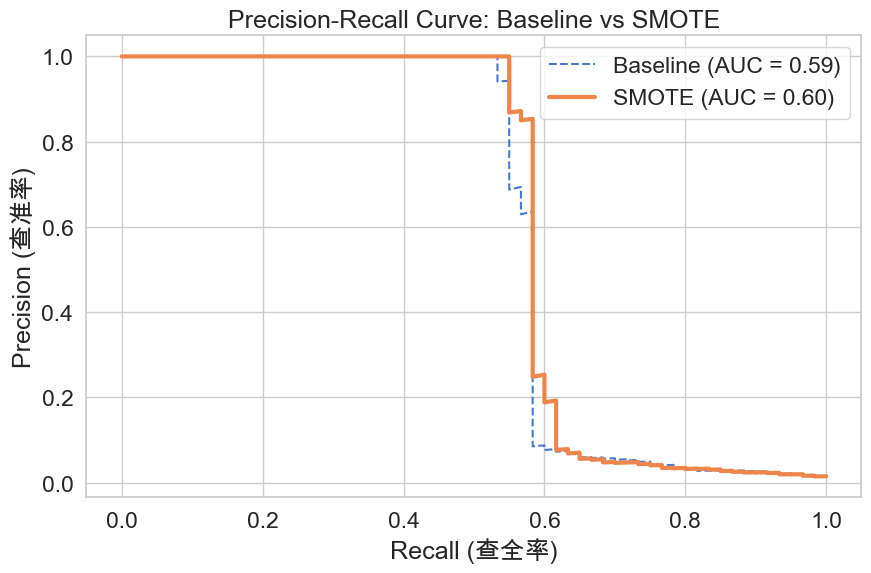

✅ 案例完成! (Evaluation Complete)


In [8]:
# 1. 计算概率 (Predict Proba)
# 我们需要"概率值"而不是"类别"来画曲线
y_prob_baseline = lr.predict_proba(X_test)[:, 1]
y_prob_smote = lr_smote.predict_proba(X_test)[:, 1]

# 2. 计算 PR Curve
precision_base, recall_base, _ = precision_recall_curve(y_test, y_prob_baseline)
precision_smote, recall_smote, _ = precision_recall_curve(y_test, y_prob_smote)

# 3. 画图
plt.figure(figsize=(10, 6))
plt.plot(recall_base, precision_base, label=f'Baseline (AUC = {auc(recall_base, precision_base):.2f})', linestyle='--')
plt.plot(recall_smote, precision_smote, label=f'SMOTE (AUC = {auc(recall_smote, precision_smote):.2f})', linewidth=3)

plt.xlabel('Recall (查全率)')
plt.ylabel('Precision (查准率)')
plt.title('Precision-Recall Curve: Baseline vs SMOTE')
plt.legend()
plt.show()

# 结论:
# SMOTE 的曲线下面积 (Area Under Curve) 通常会比 Baseline 大，
# 尤其是在高 Recall 区域，SMOTE 依然能保持一定的 Precision。

print("✅ 案例完成! (Evaluation Complete)")